# Genetic Algorithm Test
The whole point of this is to test if we can do good optimisation of measurements to limbs using gradient free methods or not. 

In [7]:
from SSM_Driver import LegMeasurementDataset, measure, MeasurementLoss
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from SSM_Driver import create_examples, create_bad_examples
import pygad
import csv
import os


In [8]:
config = {
    "lr": 1e-3,
    "eta_min": 1e-6,
    "batch_size": 1,
    "log": True,
    "seed": 42,
    "epochs":200,
    "scale": True,
    "normalise": False,
    "relativise": False,
}
dtype = torch.float64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = LegMeasurementDataset(measure, batch_size=config["batch_size"], scale=config["scale"], normalise=config["normalise"], relativise=config["relativise"], dtype=dtype, device="cpu")
dataloader = torch.utils.data.DataLoader(dataset, config["batch_size"], shuffle=False, num_workers=0)
component_transforms = torch.load("./data_components/scaled_component_transforms.pt").to(dtype).to(device)

loss = MeasurementLoss(dataset)
# loss(preds, components)

In [9]:
def step(x, y, func, lambda_=1E-3, delta=1E-6):
    # x.shape = (batch, components)
    # func(x).shape = (batch, measures)
    # y.shape = (batch, measures)
    with torch.no_grad():
        deltas = torch.eye(x.shape[1], device=x.device, dtype=x.dtype)*delta
        pos = func((x[:, None] + deltas).reshape((x.shape[0]*x.shape[1], x.shape[1]))).reshape((x.shape[0], y.shape[1], x.shape[1]))
        neg = func((x[:, None] - deltas).reshape((x.shape[0]*x.shape[1], x.shape[1]))).reshape((x.shape[0], y.shape[1], x.shape[1]))
        func_x = func(x)

        J_approx = -(pos - neg) / (2*delta)

        # Compute residuals: (batch_size, n_measures, 1)
        residuals = (y - func_x).unsqueeze(-1)

        # JTJ: (batch_size, n_components, n_components)
        JTJ = torch.bmm(J_approx.transpose(1, 2), J_approx)

        # Damping (use scalar, e.g. 1e-3)
        damping = torch.diag_embed(torch.diagonal(JTJ, dim1=1, dim2=2))

        # J^T * residuals: (batch_size, n_components, 1)
        JTr = torch.bmm(J_approx.transpose(1, 2), residuals)

        # LM step direction: (batch_size, n_components)
        x_new = x + torch.linalg.solve(JTJ + lambda_ * damping, JTr).squeeze(-1)
        new_residuals = (y - func(x_new))
        while torch.sum(residuals**2) < torch.sum(new_residuals**2):
            lambda_ *= 10
            x_new = x + torch.linalg.solve(JTJ + lambda_ * damping, JTr).squeeze(-1)
            new_residuals = (y - func(x_new))

            if lambda_ > 1E10:
                raise ValueError()

        return x_new, new_residuals, lambda_ / 10

In [10]:

class FitnessFunction:
    def __init__(self, components, loss, transforms):
        self.components = components
        self.loss = loss
        self.transforms = transforms

    def calc(self, instance, solution, idx):
        # solution is a 1D numpy array, convert to torch tensor
        pred_components = torch.tensor(solution, dtype=dtype, device=device).unsqueeze(0)
        pred_components = pred_components * self.transforms[1:] + self.transforms[:1]

        # calculate loss (negative because pygad maximizes fitness)
        loss_value = self.loss(pred_components, self.components).item()
        return -loss_value
    
    

for measures, components in dataloader:
    fitness_func = FitnessFunction(components, loss, component_transforms).calc
    num_genes = components.shape[1]
    gene_space = {'low': -3, 'high': 3}  # adjust bounds as needed

    ga_instance = pygad.GA(
        num_generations=50,
        num_parents_mating=4,
        fitness_func=fitness_func,
        sol_per_pop=32,
        num_genes=num_genes,
        gene_space=gene_space,
        parent_selection_type="sss",
        keep_parents=2,
        mutation_percent_genes=20,
        crossover_type="single_point",
        mutation_type="random"
    )

    ga_instance.run()
    best_solution, best_solution_fitness, _ = ga_instance.best_solution()

    # Refine with 10 steps of the step function
    x = torch.tensor(best_solution, dtype=dtype, device=device).unsqueeze(0)
    y = measures
    func = dataset.get_measures
    lambda_ = 1e-3
    try:
        for _ in range(10):
            x, _, lambda_ = step(x, y, func, lambda_=lambda_)
    except ValueError:
        pass
    refined_solution = x.squeeze(0).detach()

    # Use refined_solution for further evaluation
    solution_tensor = refined_solution * component_transforms[1:] + component_transforms[:1]
    solution_difference = torch.abs(dataset.get_measures(solution_tensor) - dataset.get_measures(components))
    solution_tensor = torch.tensor(best_solution, dtype=dtype, device=device) * component_transforms[1:] + component_transforms[:1]
    solution_difference = torch.abs(dataset.get_measures(solution_tensor) - dataset.get_measures(components))

    file_exists = os.path.isfile("GA_results.csv")
    with open("GA_results.csv", mode="a", newline="") as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(
            [f"measures_{i+1}" for i in range(measures.shape[1])]
            + [f"components_{i+1}" for i in range(components.shape[1])]
            + [f"solution_{i+1}" for i in range(len(best_solution))]
            + ["fitness"]
            + [f"solution_difference_{i+1}" for i in range(solution_difference.shape[1])]
            )
        writer.writerow(
            measures.cpu().numpy().flatten().tolist()
            + components.cpu().numpy().flatten().tolist()
            + best_solution.tolist()
            + [float(best_solution_fitness)]
            + solution_difference.cpu().numpy().flatten().tolist()
        )
    # print(f"Best Solution (components): {best_solution}")
    # print(f"Best Solution Fitness (negative loss): {best_solution_fitness}")
    print(f"Solution difference: {solution_difference}\n")

    break

Solution difference: tensor([[1.7915, 1.1754, 0.8410, 0.4699, 1.0286, 0.0765, 0.9297]],
       dtype=torch.float64)



In [11]:


results = np.genfromtxt("GA_results.csv", delimiter=",", skip_header=1)
# results = np.genfromtxt("GA_results-25-09-07.csv", delimiter=",", skip_header=1)
# Determine the number of measures and components from the dataset
n_measures = measures.shape[1]
n_components = components.shape[1]

# Extract columns for measures, components, and solutions from the results array
measures_arr = results[:, :n_measures]
components_arr = results[:, n_measures:n_measures + n_components]
solutions_arr = results[:, n_measures + n_components:n_measures + 2 * n_components]
# Convert to torch tensors
measures_tensor = torch.tensor(measures_arr, dtype=dtype, device=device)
components_tensor = torch.tensor(components_arr, dtype=dtype, device=device)
solutions_tensor = torch.tensor(solutions_arr, dtype=dtype, device=device) * component_transforms[1:] + component_transforms[:1]

# Get measurements in batch
true_measurements = dataset.get_measures(components_tensor)
solution_measurements = dataset.get_measures(solutions_tensor)



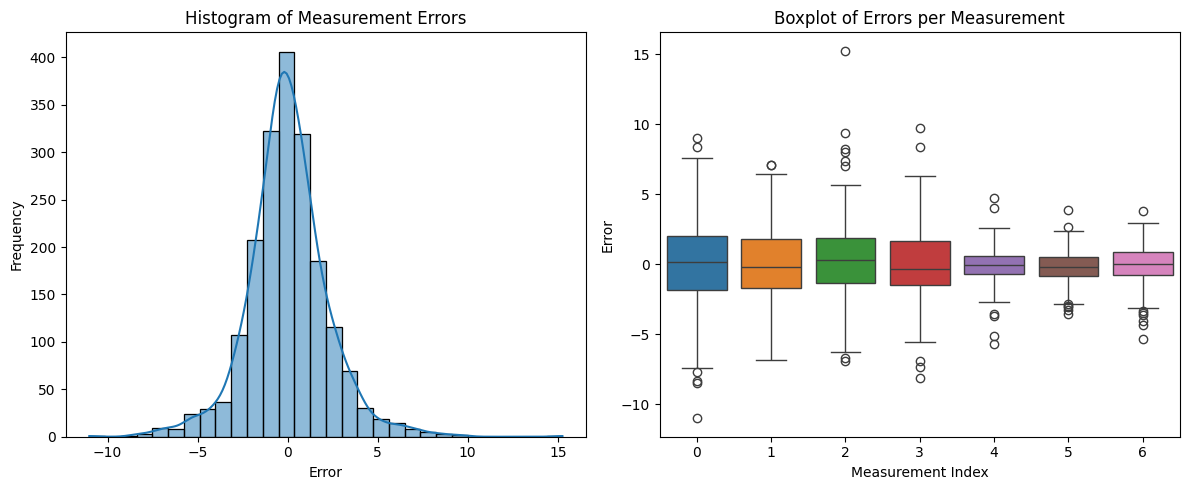

In [12]:
difference = solution_measurements - true_measurements


# Flatten the difference tensor for histogram
error_flat = difference.cpu().numpy().flatten()

plt.figure(figsize=(12, 5))

# Histogram of errors
plt.subplot(1, 2, 1)
sns.histplot(error_flat, bins=30, kde=True)
plt.title("Histogram of Measurement Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")

# Boxplot of errors per measurement
plt.subplot(1, 2, 2)
sns.boxplot(data=difference.cpu().numpy())
plt.title("Boxplot of Errors per Measurement")
plt.xlabel("Measurement Index")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

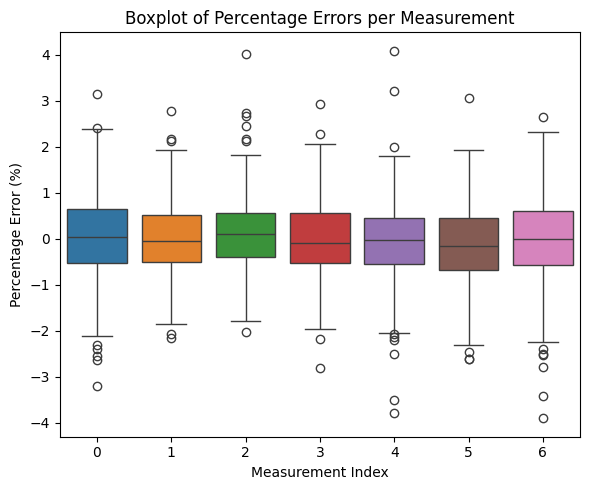

In [13]:
# Calculate relative (percentage) errors
relative_difference = difference / true_measurements * 100  # percentage error

# Flatten the relative error tensor for histogram
relative_error_flat = relative_difference.cpu().numpy().flatten()

plt.figure(figsize=(6, 5))

# Histogram of percentage errors
# plt.subplot(1, 2, 1)
# sns.histplot(relative_error_flat, bins=30, kde=True)
# plt.title("Histogram of Percentage Measurement Errors")
# plt.xlabel("Percentage Error (%)")
# plt.ylabel("Frequency")

# Boxplot of percentage errors per measurement
plt.subplot(1, 1, 1)
sns.boxplot(data=relative_difference.cpu().numpy())
plt.title("Boxplot of Percentage Errors per Measurement")
plt.xlabel("Measurement Index")
plt.ylabel("Percentage Error (%)")

plt.tight_layout()
plt.show()

In [14]:
# print(f"95% confidence interval for the mean error: [{ci_lower:.4f}, {ci_upper:.4f}]") Maybe 

In [15]:


# Calculate statistics for the error tensor
error_np = difference.cpu().numpy()  # shape: (n_samples, n_measures)

# Per-measurement statistics
mean_per_measure = error_np.mean(axis=0)
std_per_measure = error_np.std(axis=0)
min_per_measure = error_np.min(axis=0)
max_per_measure = error_np.max(axis=0)

# Overall statistics
mean_total = error_np.mean()
std_total = error_np.std()
min_total = error_np.min()
max_total = error_np.max()

# Prepare DataFrame for LaTeX table
stats_df = pd.DataFrame({
    "Mean": mean_per_measure,
    "Std": std_per_measure,
    "Min": min_per_measure,
    "Max": max_per_measure
})
stats_df.index = [f"Measurement {i+1}" for i in range(error_np.shape[1])]

# Add total row
stats_df.loc["Total"] = [mean_total, std_total, min_total, max_total]

# Format as LaTeX table
latex_table = stats_df.round(4).to_latex(escape=False)
# Print LaTeX table with trimmed trailing zeros
def trim_zeros_latex(latex_str):
    # Replace numbers like 2.0000 with 2, and 2.1000 with 2.1, etc.
    return re.sub(r'(\d+\.\d*?[1-9])0+\b', r'\1', 
           re.sub(r'(\d+)\.0+\b', r'\1', latex_str))

print(trim_zeros_latex(stats_df.round(4).to_latex(escape=False)))

\begin{tabular}{lrrrr}
\toprule
 & Mean & Std & Min & Max \\
\midrule
Measurement 1 & 0.1736 & 3.2982 & -11.0104 & 8.9956 \\
Measurement 2 & -0.0708 & 2.6365 & -6.8453 & 7.0923 \\
Measurement 3 & 0.3097 & 2.6783 & -6.928 & 15.2578 \\
Measurement 4 & 0.021 & 2.3991 & -8.145 & 9.7671 \\
Measurement 5 & -0.0814 & 1.2063 & -5.7255 & 4.722 \\
Measurement 6 & -0.1666 & 1.1669 & -3.5834 & 3.9104 \\
Measurement 7 & -0.0482 & 1.3287 & -5.3706 & 3.8383 \\
Total & 0.0196 & 2.2522 & -11.0104 & 15.2578 \\
\bottomrule
\end{tabular}



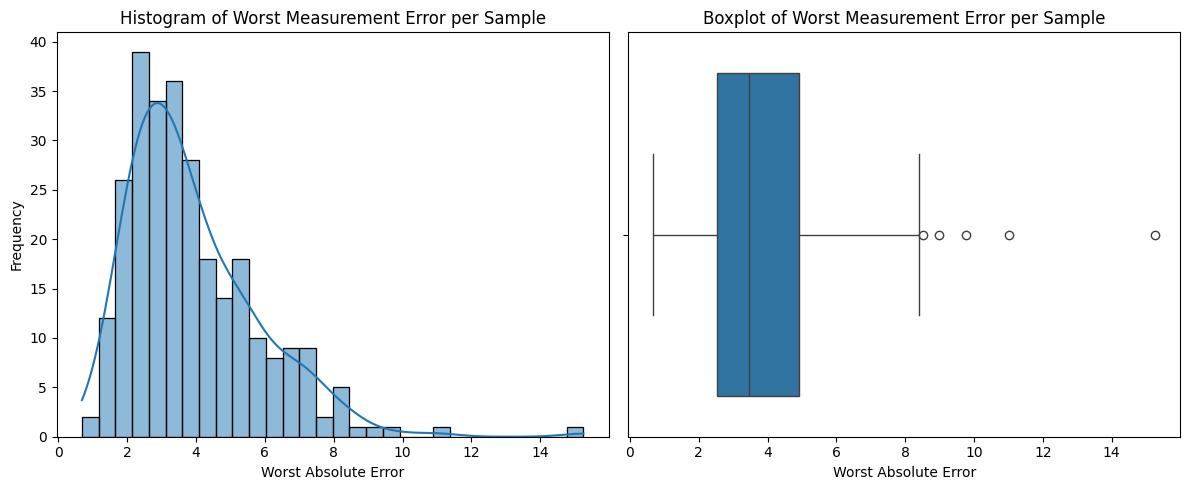

In [16]:
# Get the maximum absolute error per sample
worst_error = np.abs(difference.cpu().numpy()).max(axis=1)

plt.figure(figsize=(12, 5))

# Histogram of worst errors
plt.subplot(1, 2, 1)
sns.histplot(worst_error, bins=30, kde=True)
plt.title("Histogram of Worst Measurement Error per Sample")
plt.xlabel("Worst Absolute Error")
plt.ylabel("Frequency")

# Boxplot of worst errors
plt.subplot(1, 2, 2)
sns.boxplot(x=worst_error)
plt.title("Boxplot of Worst Measurement Error per Sample")
plt.xlabel("Worst Absolute Error")

plt.tight_layout()
plt.show()

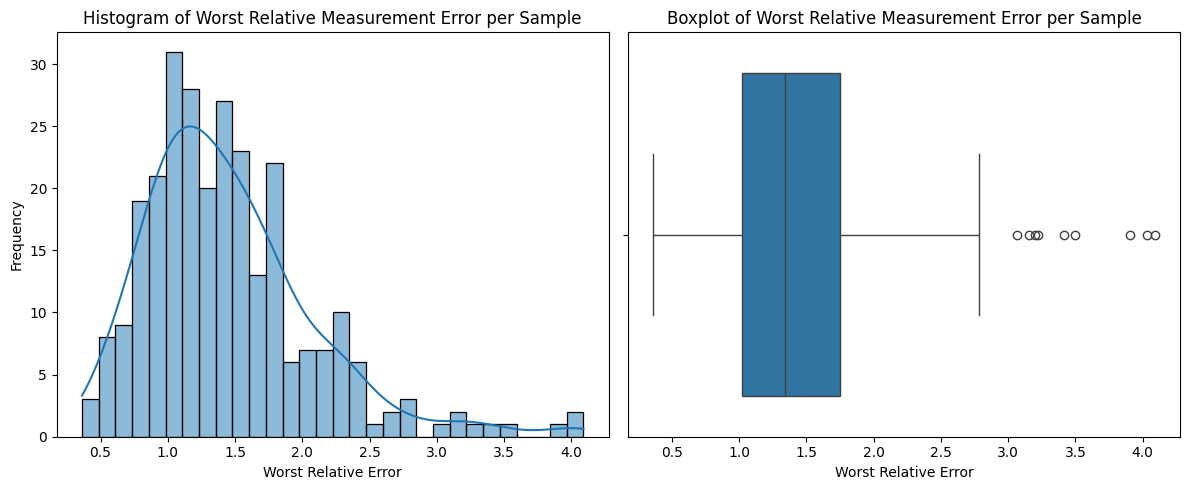

In [17]:
relative_difference = (difference / true_measurements * 100).cpu().numpy()
worst_relative = np.max(np.abs(relative_difference), axis=1)

plt.figure(figsize=(12, 5))
# Histogram of worst errors
plt.subplot(1, 2, 1)
sns.histplot(worst_relative, bins=30, kde=True)
plt.title("Histogram of Worst Relative Measurement Error per Sample")
plt.xlabel("Worst Relative Error")
plt.ylabel("Frequency")

# Boxplot of worst errors
plt.subplot(1, 2, 2)
sns.boxplot(x=worst_relative)
plt.title("Boxplot of Worst Relative Measurement Error per Sample")
plt.xlabel("Worst Relative Error")

plt.tight_layout()
plt.show()

In [24]:

# components_tensor
# solutions_tensor
create_examples(components_tensor, solutions_tensor, dataset, 5)
create_bad_examples(components_tensor, solutions_tensor, dataset, 5)